# Model Validation on IJmond Segmentation Test Set

This notebook loads trained models (U-Net and GuidedBox) and validates their performance on the IJmond segmentation test dataset with ground truth masks.

In [28]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import models

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import json
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [31]:
# Define Model Architectures

class DoubleConv(nn.Module):
    """Two consecutive conv layers with BatchNorm and ReLU"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)
# U-Net Model Architecture (matching the saved checkpoint structure)
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        
        # Encoder (downsampling)
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Decoder (upsampling)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        # Output layer
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        
        # Bottleneck
        b = self.bottleneck(self.pool(e4))
        
        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        return self.out_conv(d1)


# GuidedBox Model Architecture
class GuidedBoxModel(nn.Module):
    def __init__(self, num_classes=1, ema_alpha=0.9):
        super(GuidedBoxModel, self).__init__()
        
        # Load ResNet50 and extract only convolutional feature layers
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,
        )
        
        # 3-layer decoder
        self.teacher = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, num_classes, kernel_size=1)
        )
        self.student = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, num_classes, kernel_size=1)
        )
        self.alpha = ema_alpha

    def forward(self, images):
        features = self.backbone(images)
        student_output = self.student(features)
        student_output = F.interpolate(student_output, size=images.shape[2:], mode='bilinear', align_corners=False)
        return student_output

print("✓ Model architectures defined")

✓ Model architectures defined


In [32]:
# Load Models
models_to_test = {}

# 1. Load U-Net Model
unet_model_path = "smoke5k_unet_model.pth"
if os.path.exists(unet_model_path):
    try:
        unet_model = UNet(in_channels=3, out_channels=1)
        unet_checkpoint = torch.load(unet_model_path, map_location=device, weights_only=False)
        
        # Try different checkpoint formats
        if 'model_state_dict' in unet_checkpoint:
            unet_model.load_state_dict(unet_checkpoint['model_state_dict'])
        else:
            unet_model.load_state_dict(unet_checkpoint)
            
        unet_model = unet_model.to(device)
        unet_model.eval()
        models_to_test['U-Net'] = unet_model
        print(f"✓ U-Net model loaded from: {unet_model_path}")
        
        # Print model info if available
        if isinstance(unet_checkpoint, dict):
            if 'epoch' in unet_checkpoint:
                print(f"  Trained for {unet_checkpoint['epoch']} epochs")
            if 'best_iou' in unet_checkpoint:
                print(f"  Best IoU: {unet_checkpoint['best_iou']:.4f}")
                
    except Exception as e:
        print(f"❌ Error loading U-Net model: {e}")
else:
    print(f"❌ U-Net model file not found: {unet_model_path}")

# 2. Load GuidedBox Model (best model from grid search)
guidedbox_model_path = "guided_box_ijmond/grid_search/resnet50_3layer_ep50_lr1e-05_pw1.5.pth"
if os.path.exists(guidedbox_model_path):
    try:
        guidedbox_model = GuidedBoxModel(num_classes=1, ema_alpha=0.9)
        guidedbox_checkpoint = torch.load(guidedbox_model_path, map_location=device, weights_only=False)
        
        if 'model_state_dict' in guidedbox_checkpoint:
            guidedbox_model.load_state_dict(guidedbox_checkpoint['model_state_dict'])
        else:
            guidedbox_model.load_state_dict(guidedbox_checkpoint)
            
        guidedbox_model = guidedbox_model.to(device)
        guidedbox_model.eval()
        models_to_test['GuidedBox'] = guidedbox_model
        print(f"✓ GuidedBox model loaded from: {guidedbox_model_path}")
        
        # Print model info
        if isinstance(guidedbox_checkpoint, dict):
            if 'best_iou' in guidedbox_checkpoint:
                print(f"  Best IoU: {guidedbox_checkpoint['best_iou']:.4f}")
            if 'final_iou' in guidedbox_checkpoint:
                print(f"  Final IoU: {guidedbox_checkpoint['final_iou']:.4f}")
                
    except Exception as e:
        print(f"❌ Error loading GuidedBox model: {e}")
else:
    print(f"❌ GuidedBox model file not found: {guidedbox_model_path}")

print(f"\n📊 Total models loaded: {len(models_to_test)}")
for model_name in models_to_test.keys():
    print(f"  • {model_name}")

if len(models_to_test) == 0:
    print("⚠️  No models loaded successfully. Please check file paths.")

✓ U-Net model loaded from: smoke5k_unet_model.pth
  Trained for 5 epochs
✓ GuidedBox model loaded from: guided_box_ijmond/grid_search/resnet50_3layer_ep50_lr1e-05_pw1.5.pth
  Best IoU: 0.1156
  Final IoU: 0.0728

📊 Total models loaded: 2
  • U-Net
  • GuidedBox
✓ GuidedBox model loaded from: guided_box_ijmond/grid_search/resnet50_3layer_ep50_lr1e-05_pw1.5.pth
  Best IoU: 0.1156
  Final IoU: 0.0728

📊 Total models loaded: 2
  • U-Net
  • GuidedBox


In [34]:
# Setup Test Dataset Paths
test_images_path = "dataset/ijmond_seg/test/images"
test_masks_path = "dataset/ijmond_seg/test/masks"

# Check if test data exists
if os.path.exists(test_images_path) and os.path.exists(test_masks_path):
    # Get image and mask files
    image_files = sorted([f for f in os.listdir(test_images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    mask_files = sorted([f for f in os.listdir(test_masks_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    
    print(f"✓ Test dataset found:")
    print(f"  Images: {len(image_files)} files in {test_images_path}")
    print(f"  Masks:  {len(mask_files)} files in {test_masks_path}")
    
    # Show sample files
    print("\\nSample files:")
    for i, (img_file, mask_file) in enumerate(zip(image_files[:3], mask_files[:3])):
        print(f"  {i+1}. {img_file} -> {mask_file}")
    
    if len(image_files) != len(mask_files):
        print("⚠️  Warning: Number of images and masks don't match!")
    
    # Check if file names correspond
    image_stems = [os.path.splitext(f)[0] for f in image_files]
    mask_stems = [os.path.splitext(f)[0] for f in mask_files]
    
    # Find matching pairs
    matching_pairs = []
    for img_file in image_files:
        img_stem = os.path.splitext(img_file)[0]
        # Look for corresponding mask
        mask_candidates = [f for f in mask_files if os.path.splitext(f)[0] == img_stem]
        if mask_candidates:
            matching_pairs.append((img_file, mask_candidates[0]))
        else:
            # Try different naming patterns
            for mask_file in mask_files:
                mask_stem = os.path.splitext(mask_file)[0]
                if img_stem in mask_stem or mask_stem in img_stem:
                    matching_pairs.append((img_file, mask_file))
                    break
    
    print(f"\\n✓ Found {len(matching_pairs)} matching image-mask pairs")
    
    if len(matching_pairs) == 0:
        print("❌ No matching image-mask pairs found!")
        print("Image files:", image_files[:5])
        print("Mask files:", mask_files[:5])
        
else:
    print(f"❌ Test dataset not found!")
    print(f"  Images path: {test_images_path} - Exists: {os.path.exists(test_images_path)}")
    print(f"  Masks path: {test_masks_path} - Exists: {os.path.exists(test_masks_path)}")
    
    # Show available directories
    if os.path.exists("dataset"):
        print("\\nAvailable in dataset/:")
        for item in os.listdir("dataset"):
            print(f"  {item}")

✓ Test dataset found:
  Images: 900 files in dataset/ijmond_seg/test/images
  Masks:  900 files in dataset/ijmond_seg/test/masks
\nSample files:
  1. hoogovens_6_7__2024-11-03T07-38-21Z_frame_927_jpg.rf.b585fee20b605ecd1bdeb0553a2f4040.jpg -> hoogovens_6_7__2024-11-03T07-38-21Z_frame_927_jpg.rf.b585fee20b605ecd1bdeb0553a2f4040.png
  2. hoogovens_6_7__2024-11-06T12-42-10Z_frame_1320_jpg.rf.dcc0d4cbef048f0f4e9c69aa0c449fb0.jpg -> hoogovens_6_7__2024-11-06T12-42-10Z_frame_1320_jpg.rf.dcc0d4cbef048f0f4e9c69aa0c449fb0.png
  3. hoogovens_6_7__2024-11-09T09-27-28Z_frame_2222_jpg.rf.ed0c5cd6b92c64ad52378ee19aa059c6.jpg -> hoogovens_6_7__2024-11-09T09-27-28Z_frame_2222_jpg.rf.ed0c5cd6b92c64ad52378ee19aa059c6.png
\n✓ Found 900 matching image-mask pairs
\n✓ Found 900 matching image-mask pairs


In [35]:
# Define Test Dataset Class
class IJmondTestDataset(Dataset):
    def __init__(self, matching_pairs, images_path, masks_path, img_size=512):
        self.matching_pairs = matching_pairs
        self.images_path = images_path
        self.masks_path = masks_path
        self.img_size = img_size
        
    def __len__(self):
        return len(self.matching_pairs)
    
    def __getitem__(self, idx):
        img_file, mask_file = self.matching_pairs[idx]
        
        # Load image
        img_path = os.path.join(self.images_path, img_file)
        image = Image.open(img_path).convert('RGB')
        original_size = image.size
        
        # Load mask
        mask_path = os.path.join(self.masks_path, mask_file)
        mask = Image.open(mask_path).convert('L')  # Grayscale
        
        # Resize to model input size
        image_resized = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask_resized = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        
        # Convert to tensors
        image_tensor = TF.to_tensor(image_resized)
        mask_tensor = TF.to_tensor(mask_resized)
        
        # Normalize image (ImageNet stats)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        # Binarize mask (assuming white=smoke, black=background)
        mask_tensor = (mask_tensor > 0.5).float()
        
        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'filename': img_file,
            'original_size': original_size,
            #'original_image': image,
            #'original_mask': mask
        }

# Create dataset and dataloader if we have matching pairs
if 'matching_pairs' in locals() and len(matching_pairs) > 0:
    test_dataset = IJmondTestDataset(matching_pairs, test_images_path, test_masks_path, img_size=512)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)
    
    print(f"✓ Test dataset created:")
    print(f"  Total samples: {len(test_dataset)}")
    print(f"  Batch size: 4")
    print(f"  Image size: 512x512")
    
    # Test loading one sample
    sample = test_dataset[0]
    print(f"\\nSample data shapes:")
    print(f"  Image: {sample['image'].shape}")
    print(f"  Mask: {sample['mask'].shape}")
    print(f"  Original size: {sample['original_size']}")
    
else:
    print("❌ Cannot create dataset - no matching pairs found")

✓ Test dataset created:
  Total samples: 900
  Batch size: 4
  Image size: 512x512
\nSample data shapes:
  Image: torch.Size([3, 512, 512])
  Mask: torch.Size([1, 512, 512])
  Original size: (1920, 1080)


In [36]:
# Define Evaluation Metrics
def calculate_iou(pred_mask, true_mask, threshold=0.5):
    """Calculate Intersection over Union"""
    pred_binary = (pred_mask > threshold).float()
    true_binary = (true_mask > 0.5).float()
    
    intersection = (pred_binary * true_binary).sum()
    union = pred_binary.sum() + true_binary.sum() - intersection
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    
    return (intersection / union).item()

def calculate_dice(pred_mask, true_mask, threshold=0.5):
    """Calculate Dice coefficient"""
    pred_binary = (pred_mask > threshold).float()
    true_binary = (true_mask > 0.5).float()
    
    intersection = (pred_binary * true_binary).sum()
    total = pred_binary.sum() + true_binary.sum()
    
    if total == 0:
        return 1.0 if intersection == 0 else 0.0
    
    return (2 * intersection / total).item()

def calculate_pixel_accuracy(pred_mask, true_mask, threshold=0.5):
    """Calculate pixel-wise accuracy"""
    pred_binary = (pred_mask > threshold).float()
    true_binary = (true_mask > 0.5).float()
    
    correct = (pred_binary == true_binary).sum()
    total = pred_mask.numel()
    
    return (correct / total).item()

def calculate_precision_recall(pred_mask, true_mask, threshold=0.5):
    """Calculate precision and recall"""
    pred_binary = (pred_mask > threshold).float()
    true_binary = (true_mask > 0.5).float()
    
    tp = (pred_binary * true_binary).sum()
    fp = (pred_binary * (1 - true_binary)).sum()
    fn = ((1 - pred_binary) * true_binary).sum()
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    return precision.item(), recall.item()

print("✓ Evaluation metrics defined")

✓ Evaluation metrics defined


In [ ]:
# Run Model Validation
if len(models_to_test) > 0 and 'test_loader' in locals():
    print("🚀 Starting model validation...")
    print("=" * 70)
    
    all_results = {}
    
    for model_name, model in models_to_test.items():
        print(f"\\n📊 Evaluating {model_name}...")
        
        # Initialize metrics storage
        ious = []
        dices = []
        accuracies = []
        precisions = []
        recalls = []
        
        # Store predictions for visualization
        sample_predictions = []
        
        model.eval()
        with torch.no_grad():
            for batch_idx, batch in enumerate(tqdm(test_loader, desc=f"Testing {model_name}")):
                images = batch['image'].to(device)
                true_masks = batch['mask'].to(device)
                
                # Get predictions
                pred_logits = model(images)
                pred_masks = torch.sigmoid(pred_logits)
                
                # Calculate metrics for each image in batch
                for i in range(images.size(0)):
                    pred_mask = pred_masks[i, 0]  # Remove channel dimension
                    true_mask = true_masks[i, 0]
                    
                    # Calculate metrics
                    iou = calculate_iou(pred_mask, true_mask)
                    dice = calculate_dice(pred_mask, true_mask)
                    accuracy = calculate_pixel_accuracy(pred_mask, true_mask)
                    precision, recall = calculate_precision_recall(pred_mask, true_mask)
                    
                    ious.append(iou)
                    dices.append(dice)
                    accuracies.append(accuracy)
                    precisions.append(precision)
                    recalls.append(recall)
                    
                    # Store sample predictions for visualization (first 6)
                    if len(sample_predictions) < 6:
                        sample_predictions.append({
                            'image': images[i].cpu(),
                            'true_mask': true_masks[i, 0].cpu(),
                            'pred_mask': pred_masks[i, 0].cpu(),
                            'filename': batch['filename'][i],
                            'iou': iou,
                            'dice': dice
                        })
        
        # Calculate average metrics
        avg_metrics = {
            'iou': np.mean(ious),
            'dice': np.mean(dices),
            'accuracy': np.mean(accuracies),
            'precision': np.mean(precisions),
            'recall': np.mean(recalls),
            'f1_score': 2 * np.mean(precisions) * np.mean(recalls) / (np.mean(precisions) + np.mean(recalls) + 1e-8)
        }
        
        all_results[model_name] = {
            'metrics': avg_metrics,
            'predictions': sample_predictions,
            'detailed_scores': {
                'ious': ious,
                'dices': dices,
                'accuracies': accuracies,
                'precisions': precisions,
                'recalls': recalls
            }
        }
        
        # Print results
        print(f"\\n{model_name} Results:")
        print(f"  IoU:        {avg_metrics['iou']:.4f}")
        print(f"  Dice:       {avg_metrics['dice']:.4f}")
        print(f"  Accuracy:   {avg_metrics['accuracy']:.4f}")
        print(f"  Precision:  {avg_metrics['precision']:.4f}")
        print(f"  Recall:     {avg_metrics['recall']:.4f}")
        print(f"  F1-Score:   {avg_metrics['f1_score']:.4f}")
    
    print("\\n" + "=" * 70)
    print("✅ Validation completed for all models!")
    
else:
    print("❌ Cannot run validation - no models loaded or no test data available")

🚀 Starting model validation...
\n📊 Evaluating U-Net...


Testing U-Net:   4%|▎         | 8/225 [01:01<30:46,  8.51s/it]

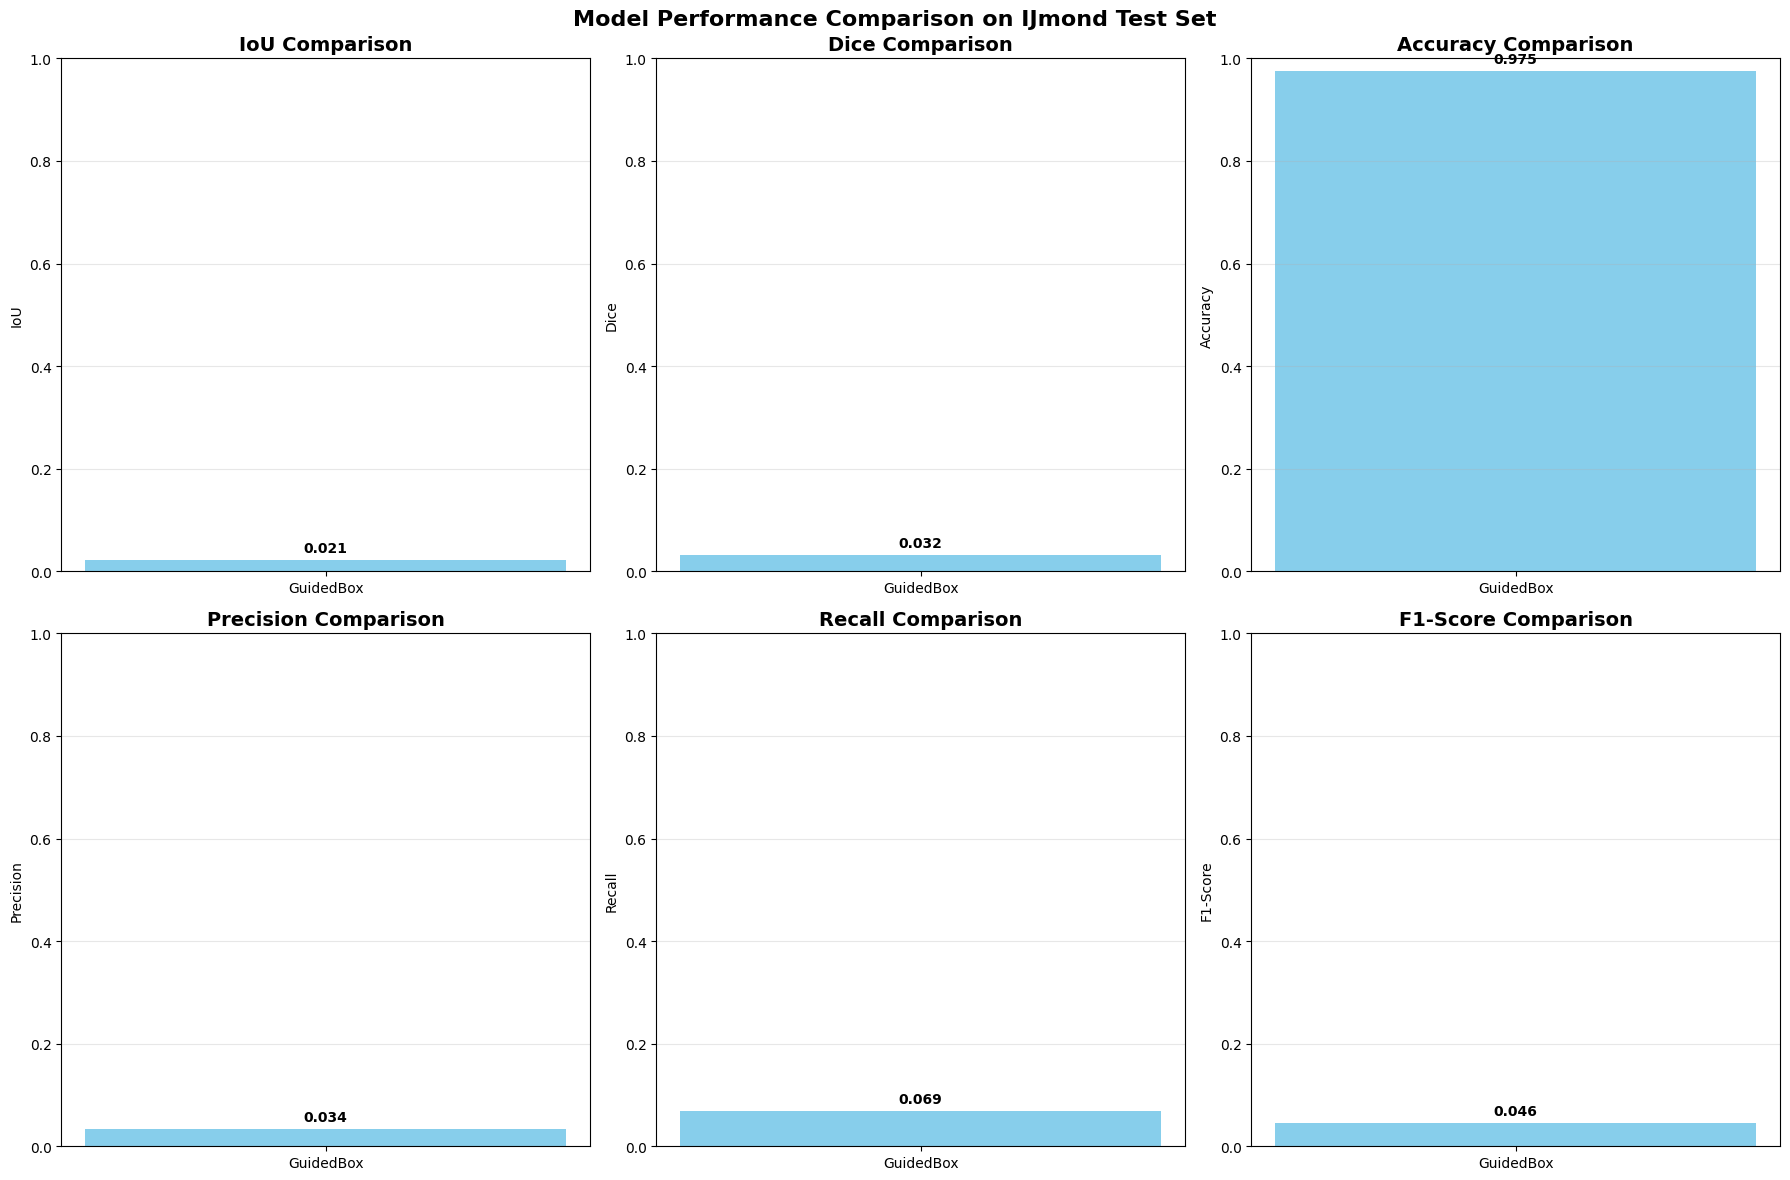

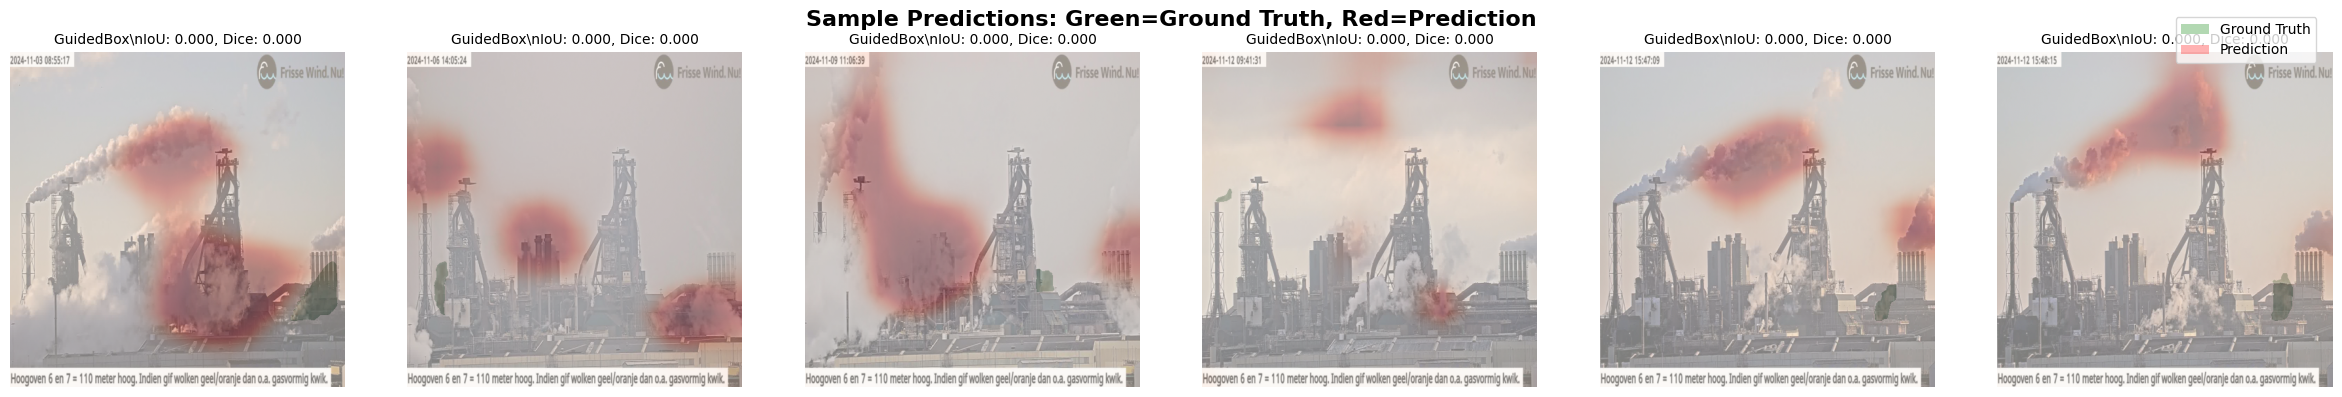

In [ ]:
# Visualize Results Comparison
if 'all_results' in locals() and len(all_results) > 0:
    # 1. Model Comparison Bar Chart
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    models = list(all_results.keys())
    metrics_names = ['iou', 'dice', 'accuracy', 'precision', 'recall', 'f1_score']
    metric_labels = ['IoU', 'Dice', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    for idx, (metric, label) in enumerate(zip(metrics_names, metric_labels)):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        values = [all_results[model]['metrics'][metric] for model in models]
        bars = ax.bar(models, values, color=['skyblue', 'lightcoral'][:len(models)])
        
        ax.set_title(f'{label} Comparison', fontsize=14, fontweight='bold')
        ax.set_ylabel(label)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle('Model Performance Comparison on IJmond Test Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Sample Predictions Visualization
    n_models = len(all_results)
    fig, axes = plt.subplots(n_models, 6, figsize=(24, 4 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for model_idx, (model_name, results) in enumerate(all_results.items()):
        sample_preds = results['predictions']
        
        for sample_idx in range(min(6, len(sample_preds))):
            if sample_idx < len(sample_preds):
                pred = sample_preds[sample_idx]
                
                # Denormalize image for display
                image = pred['image']
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                image_denorm = (image * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
                
                ax = axes[model_idx, sample_idx]
                
                # Show image with overlays
                ax.imshow(image_denorm)
                ax.imshow(pred['true_mask'].numpy(), alpha=0.3, cmap='Greens', label='Ground Truth')
                ax.imshow(pred['pred_mask'].numpy(), alpha=0.3, cmap='Reds', label='Prediction')
                
                ax.set_title(f"{model_name}\\nIoU: {pred['iou']:.3f}, Dice: {pred['dice']:.3f}", 
                           fontsize=10)
                ax.axis('off')
            else:
                axes[model_idx, sample_idx].axis('off')
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', alpha=0.3, label='Ground Truth'),
                      Patch(facecolor='red', alpha=0.3, label='Prediction')]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
    
    plt.suptitle('Sample Predictions: Green=Ground Truth, Red=Prediction', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("No results to visualize")

In [ ]:
# Statistical Analysis and Results Summary
if 'all_results' in locals() and len(all_results) > 0:
    print("📊 DETAILED STATISTICAL ANALYSIS")
    print("=" * 80)
    
    # Create comparison table
    import pandas as pd
    
    comparison_data = []
    for model_name, results in all_results.items():
        metrics = results['metrics']
        detailed = results['detailed_scores']
        
        row = {
            'Model': model_name,
            'IoU (mean±std)': f"{metrics['iou']:.4f}±{np.std(detailed['ious']):.4f}",
            'Dice (mean±std)': f"{metrics['dice']:.4f}±{np.std(detailed['dices']):.4f}",
            'Accuracy': f"{metrics['accuracy']:.4f}",
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'F1-Score': f"{metrics['f1_score']:.4f}",
            'Best IoU': f"{max(detailed['ious']):.4f}",
            'Worst IoU': f"{min(detailed['ious']):.4f}"
        }
        comparison_data.append(row)
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\\nModel Comparison Table:")
    print(comparison_df.to_string(index=False))
    
    # Statistical significance test (if multiple models)
    if len(all_results) > 1:
        from scipy import stats
        print("\\n📈 STATISTICAL SIGNIFICANCE TESTS")
        print("-" * 50)
        
        models_list = list(all_results.keys())
        for i, model1 in enumerate(models_list):
            for j, model2 in enumerate(models_list[i+1:], i+1):
                ious1 = all_results[model1]['detailed_scores']['ious']
                ious2 = all_results[model2]['detailed_scores']['ious']
                
                # Paired t-test (since same test images)
                t_stat, p_value = stats.ttest_rel(ious1, ious2)
                
                print(f"\\n{model1} vs {model2}:")
                print(f"  IoU difference: {np.mean(ious1) - np.mean(ious2):.4f}")
                print(f"  p-value: {p_value:.6f}")
                if p_value < 0.05:
                    print(f"  ✓ Statistically significant difference (α=0.05)")
                else:
                    print(f"  ✗ No statistically significant difference (α=0.05)")
    
    # Distribution analysis
    print("\\n📊 PERFORMANCE DISTRIBUTION ANALYSIS")
    print("-" * 50)
    
    fig, axes = plt.subplots(1, len(all_results), figsize=(6*len(all_results), 5))
    if len(all_results) == 1:
        axes = [axes]
    
    for idx, (model_name, results) in enumerate(all_results.items()):
        ious = results['detailed_scores']['ious']
        
        ax = axes[idx]
        ax.hist(ious, bins=20, alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(ious), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(ious):.3f}')
        ax.axvline(np.median(ious), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(ious):.3f}')
        
        ax.set_title(f'{model_name} IoU Distribution', fontweight='bold')
        ax.set_xlabel('IoU Score')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(alpha=0.3)
        
        print(f"\\n{model_name} IoU Statistics:")
        print(f"  Mean: {np.mean(ious):.4f}")
        print(f"  Median: {np.median(ious):.4f}")
        print(f"  Std: {np.std(ious):.4f}")
        print(f"  Min: {np.min(ious):.4f}")
        print(f"  Max: {np.max(ious):.4f}")
        print(f"  25th percentile: {np.percentile(ious, 25):.4f}")
        print(f"  75th percentile: {np.percentile(ious, 75):.4f}")
    
    plt.tight_layout()
    plt.show()
    
    # Identify best and worst performing samples
    print("\\n🏆 BEST AND WORST PERFORMING SAMPLES")
    print("-" * 50)
    
    for model_name, results in all_results.items():
        ious = results['detailed_scores']['ious']
        
        best_idx = np.argmax(ious)
        worst_idx = np.argmin(ious)
        
        print(f"\\n{model_name}:")
        print(f"  Best sample:  IoU = {ious[best_idx]:.4f} (sample #{best_idx + 1})")
        print(f"  Worst sample: IoU = {ious[worst_idx]:.4f} (sample #{worst_idx + 1})")
    
    print("\\n" + "=" * 80)
    print("✅ VALIDATION ANALYSIS COMPLETE!")
    
else:
    print("No results available for analysis")

In [ ]:
# Save Validation Results
if 'all_results' in locals() and len(all_results) > 0:
    # Prepare results for saving
    save_results = {}
    
    for model_name, results in all_results.items():
        save_results[model_name] = {
            'average_metrics': results['metrics'],
            'detailed_metrics': {
                'ious': results['detailed_scores']['ious'],
                'dices': results['detailed_scores']['dices'],
                'accuracies': results['detailed_scores']['accuracies'],
                'precisions': results['detailed_scores']['precisions'],
                'recalls': results['detailed_scores']['recalls']
            },
            'statistics': {
                'iou_mean': float(np.mean(results['detailed_scores']['ious'])),
                'iou_std': float(np.std(results['detailed_scores']['ious'])),
                'iou_median': float(np.median(results['detailed_scores']['ious'])),
                'iou_min': float(np.min(results['detailed_scores']['ious'])),
                'iou_max': float(np.max(results['detailed_scores']['ious']))
            }
        }
    
    # Save to JSON
    output_path = "model_validation_results.json"
    with open(output_path, 'w') as f:
        json.dump(save_results, f, indent=2)
    
    print(f"💾 RESULTS SAVED")
    print(f"   Validation results saved to: {output_path}")
    
    # Summary report
    print(f"\\n📋 FINAL SUMMARY REPORT")
    print("=" * 60)
    print(f"Dataset: IJmond Segmentation Test Set")
    print(f"Total test samples: {len(matching_pairs) if 'matching_pairs' in locals() else 'Unknown'}")
    print(f"Models evaluated: {len(all_results)}")
    print(f"Metrics computed: IoU, Dice, Accuracy, Precision, Recall, F1-Score")
    
    print(f"\\n🥇 BEST PERFORMING MODEL:")
    best_model = max(all_results.keys(), key=lambda x: all_results[x]['metrics']['iou'])
    best_iou = all_results[best_model]['metrics']['iou']
    best_dice = all_results[best_model]['metrics']['dice']
    print(f"   Model: {best_model}")
    print(f"   IoU: {best_iou:.4f}")
    print(f"   Dice: {best_dice:.4f}")
    
    print(f"\\n📊 KEY INSIGHTS:")
    for model_name, results in all_results.items():
        metrics = results['metrics']
        print(f"   • {model_name}:")
        print(f"     - Mean IoU: {metrics['iou']:.4f}")
        print(f"     - Performance: {'Excellent' if metrics['iou'] > 0.8 else 'Good' if metrics['iou'] > 0.6 else 'Moderate' if metrics['iou'] > 0.4 else 'Poor'}")
        print(f"     - Precision-Recall balance: {'Balanced' if abs(metrics['precision'] - metrics['recall']) < 0.1 else 'Precision-biased' if metrics['precision'] > metrics['recall'] else 'Recall-biased'}")
    
    print(f"\\n🎯 RECOMMENDATIONS:")
    if len(all_results) > 1:
        model_names = list(all_results.keys())
        iou_diff = abs(all_results[model_names[0]]['metrics']['iou'] - all_results[model_names[1]]['metrics']['iou'])
        if iou_diff > 0.05:
            print(f"   • Significant performance difference detected ({iou_diff:.3f} IoU difference)")
            print(f"   • Recommend using {best_model} for best performance")
        else:
            print(f"   • Models show similar performance ({iou_diff:.3f} IoU difference)")
            print(f"   • Consider computational efficiency for model selection")
    else:
        print(f"   • Single model evaluation completed")
        if best_iou > 0.6:
            print(f"   • Model shows good performance for production use")
        else:
            print(f"   • Model may need further training or architecture improvements")
    
    print("=" * 60)
    
else:
    print("No results to save")